<a href="https://colab.research.google.com/github/chlalswp/MyungKyuYi_ai_class-61354_003-/blob/main/car_logistic_regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 자동차 평가 데이터(Car Evaluation) 로지스틱 회귀

`car.data`로 자동차의 **수용 등급(class)** 을 예측하는 다중 클래스 로지스틱 회귀 모델을 만듭니다.

| 컬럼 | 의미 | 값 |
|---|---|---|
| buying | 구매 가격 | vhigh, high, med, low |
| maint | 유지비 | vhigh, high, med, low |
| doors | 문 개수 | 2, 3, 4, 5more |
| persons | 탑승 인원 | 2, 4, more |
| lug_boot | 트렁크 크기 | small, med, big |
| safety | 안전성 | low, med, high |
| **class** (타깃) | 평가 등급 | unacc < acc < good < vgood |

진행 순서: ① 데이터 불러오기 → ② 탐색 → ③ 인코딩 → ④ 학습/테스트 분리 → ⑤ 모델 학습 → ⑥ 평가 → ⑦ 계수 해석 → ⑧ 새 데이터 예측

## 1. 라이브러리 불러오기

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, ConfusionMatrixDisplay)

RANDOM_STATE = 42

## 2. 데이터 업로드 및 불러오기
아래 셀을 실행하면 파일 선택 창이 뜹니다. `car.data` 파일을 선택하세요.
(파일에 헤더가 없으므로 컬럼 이름을 직접 지정합니다.)

In [ ]:
try:
    from google.colab import files
    uploaded = files.upload()               # car.data 선택
    file_name = list(uploaded.keys())[0]
except ImportError:                          # Colab이 아닌 환경에서 실행할 때
    file_name = 'car.data'

columns = ['buying', 'maint', 'doors', 'persons', 'lug_boot', 'safety', 'class']
df = pd.read_csv(file_name, header=None, names=columns)

print('데이터 크기:', df.shape)
df.head()

데이터 크기: (1728, 7)


,buying,maint,doors,persons,lug_boot,safety,class
0,vhigh,vhigh,2,2,small,low,unacc
1,vhigh,vhigh,2,2,small,med,unacc
2,vhigh,vhigh,2,2,small,high,unacc
3,vhigh,vhigh,2,2,med,low,unacc
4,vhigh,vhigh,2,2,med,med,unacc


## 3. 데이터 탐색

In [ ]:
print('결측치 개수:\n', df.isnull().sum(), '\n')
for col in df.columns:
    print(f'{col:9s}:', df[col].value_counts().to_dict())

결측치 개수:
 buying      0
maint       0
doors       0
persons     0
lug_boot    0
safety      0
class       0
dtype: int64 

buying   : {'vhigh': 432, 'high': 432, 'med': 432, 'low': 432}
maint    : {'vhigh': 432, 'high': 432, 'med': 432, 'low': 432}
doors    : {'2': 432, '3': 432, '4': 432, '5more': 432}
persons  : {'2': 576, '4': 576, 'more': 576}
lug_boot : {'small': 576, 'med': 576, 'big': 576}
safety   : {'low': 576, 'med': 576, 'high': 576}
class    : {'unacc': 1210, 'acc': 384, 'good': 69, 'vgood': 65}


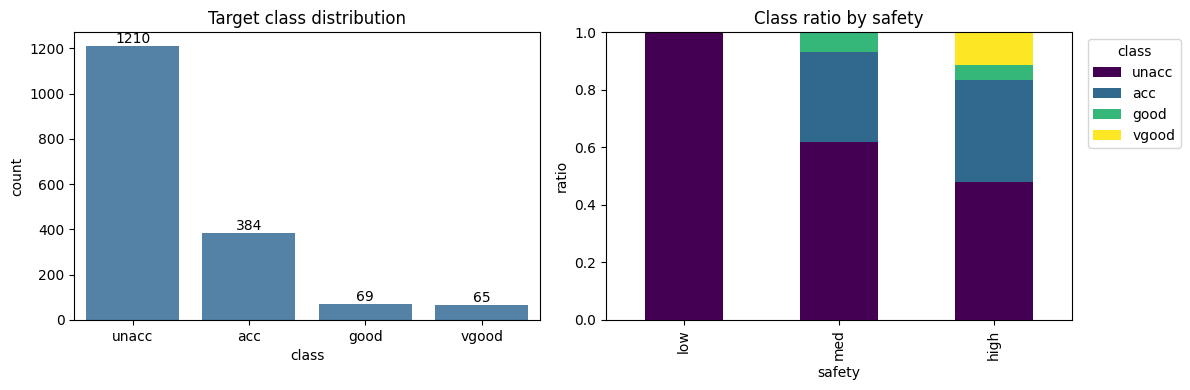

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

order = ['unacc', 'acc', 'good', 'vgood']
sns.countplot(data=df, x='class', order=order, ax=axes[0], color='steelblue')
axes[0].set_title('Target class distribution')
for p in axes[0].patches:
    axes[0].annotate(int(p.get_height()), (p.get_x() + p.get_width()/2, p.get_height()),
                     ha='center', va='bottom')

pd.crosstab(df['safety'], df['class'], normalize='index')[order] \
  .loc[['low', 'med', 'high']].plot(kind='bar', stacked=True, ax=axes[1], colormap='viridis')
axes[1].set_title('Class ratio by safety')
axes[1].set_ylabel('ratio')
axes[1].legend(title='class', bbox_to_anchor=(1.02, 1))
plt.tight_layout()
plt.show()

> **관찰:** `unacc`가 약 70%를 차지하는 **불균형 데이터**입니다. 그래서 정확도만 보면 안 되고, 클래스별 precision/recall과 macro F1도 함께 확인해야 합니다.
> 또 안전성이 `low`면 모두 `unacc`로, 안전성이 가장 중요한 변수 중 하나임을 알 수 있습니다.

## 4. 인코딩
모든 특성이 **순서가 있는 범주형(ordinal)** 이므로 `OrdinalEncoder`로 순서를 지정해 숫자로 바꿉니다.
(예: safety → low=0, med=1, high=2)
타깃도 unacc=0, acc=1, good=2, vgood=3으로 변환합니다.

In [ ]:
feature_cols = ['buying', 'maint', 'doors', 'persons', 'lug_boot', 'safety']
categories = [
    ['low', 'med', 'high', 'vhigh'],   # buying  (싼 것 → 비싼 것)
    ['low', 'med', 'high', 'vhigh'],   # maint
    ['2', '3', '4', '5more'],          # doors
    ['2', '4', 'more'],                # persons
    ['small', 'med', 'big'],           # lug_boot
    ['low', 'med', 'high'],            # safety
]
class_order = ['unacc', 'acc', 'good', 'vgood']

X_raw = df[feature_cols].astype(str)
y = df['class'].map({c: i for i, c in enumerate(class_order)})

ord_enc = OrdinalEncoder(categories=categories)
X = pd.DataFrame(ord_enc.fit_transform(X_raw), columns=feature_cols)
X.head()

,buying,maint,doors,persons,lug_boot,safety
0,3.0,3.0,0.0,0.0,0.0,0.0
1,3.0,3.0,0.0,0.0,0.0,1.0
2,3.0,3.0,0.0,0.0,0.0,2.0
3,3.0,3.0,0.0,0.0,1.0,0.0
4,3.0,3.0,0.0,0.0,1.0,1.0


## 5. 학습 / 테스트 데이터 분리
클래스 비율을 유지하도록 `stratify=y`를 사용하고, 8:2로 나눕니다.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE)

print('학습 데이터:', X_train.shape, ' 테스트 데이터:', X_test.shape)
print('학습 클래스 비율:\n', y_train.value_counts(normalize=True).sort_index().round(3))

학습 데이터: (1382, 6)  테스트 데이터: (346, 6)
학습 클래스 비율:
 class
0    0.700
1    0.222
2    0.040
3    0.038
Name: proportion, dtype: float64


## 6. 로지스틱 회귀 모델 학습
클래스가 4개이므로 **다항(multinomial) 로지스틱 회귀**가 됩니다 (scikit-learn의 기본 `lbfgs` solver가 자동으로 softmax 방식 사용).
- `max_iter=1000`: 수렴 경고 방지
- `C`: 규제 강도의 역수 (작을수록 강한 규제)

In [ ]:
model = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print(f'테스트 정확도: {accuracy_score(y_test, y_pred):.4f}')

테스트 정확도: 0.8006


## 7. 모델 평가

              precision    recall  f1-score   support

       unacc      0.862     0.930     0.895       242
         acc      0.609     0.545     0.575        77
        good      0.429     0.214     0.286        14
       vgood      0.778     0.538     0.636        13

    accuracy                          0.801       346
   macro avg      0.669     0.557     0.598       346
weighted avg      0.785     0.801     0.789       346



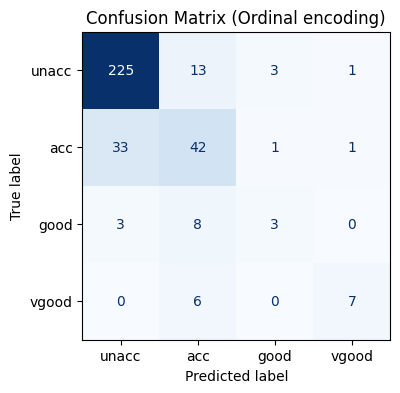

In [ ]:
print(classification_report(y_test, y_pred, target_names=class_order, digits=3, zero_division=0))

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred), display_labels=class_order) \
    .plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title('Confusion Matrix (Ordinal encoding)')
plt.show()

> 순서형 인코딩은 “각 변수의 효과가 한 단계 오를 때마다 똑같이 증가한다”는 **선형 가정**을 둡니다.
> 하지만 실제로는 `persons=2`면 무조건 unacc, `safety=low`면 무조건 unacc처럼 **특정 값에서 급격히 바뀌는 규칙**이 있어 이 가정이 잘 맞지 않습니다.
> 그래서 good·vgood 같은 소수 클래스의 recall이 낮게 나옵니다. 다음 단계에서 이를 개선합니다.

## 8. 성능 개선: 원-핫 인코딩 + 클래스 가중치
- **원-핫 인코딩**: 각 범주 값마다 별도의 계수를 학습하므로 비선형적인 영향도 표현할 수 있습니다.
- **`class_weight='balanced'`**: 개수가 적은 클래스(good, vgood)의 오분류에 더 큰 벌점을 줍니다.

네 가지 조합을 5-겹 교차검증(macro F1 기준)으로 비교합니다.

In [ ]:
oh_enc = OneHotEncoder(categories=categories, sparse_output=False)
X_oh = pd.DataFrame(oh_enc.fit_transform(X_raw), columns=oh_enc.get_feature_names_out(feature_cols))
X_oh_train, X_oh_test = X_oh.loc[X_train.index], X_oh.loc[X_test.index]

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
results = []
for enc_name, Xtr in [('Ordinal', X_train), ('One-hot', X_oh_train)]:
    for cw in [None, 'balanced']:
        clf = LogisticRegression(max_iter=5000, C=10, class_weight=cw, random_state=RANDOM_STATE)
        f1 = cross_val_score(clf, Xtr, y_train, cv=cv, scoring='f1_macro')
        acc = cross_val_score(clf, Xtr, y_train, cv=cv, scoring='accuracy')
        results.append({'encoding': enc_name, 'class_weight': str(cw),
                        'CV accuracy': acc.mean().round(4), 'CV macro F1': f1.mean().round(4)})

pd.DataFrame(results).sort_values('CV macro F1', ascending=False)

,encoding,class_weight,CV accuracy,CV macro F1
3,One-hot,balanced,0.9313,0.8872
2,One-hot,None,0.9284,0.8554
1,Ordinal,balanced,0.8089,0.7339
0,Ordinal,None,0.8357,0.7196


### 최종 모델 (원-핫 + balanced)로 테스트 데이터 평가

테스트 정확도: 0.9162

              precision    recall  f1-score   support

       unacc      1.000     0.917     0.957       242
         acc      0.778     0.909     0.838        77
        good      0.750     0.857     0.800        14
       vgood      0.722     1.000     0.839        13

    accuracy                          0.916       346
   macro avg      0.812     0.921     0.858       346
weighted avg      0.930     0.916     0.920       346



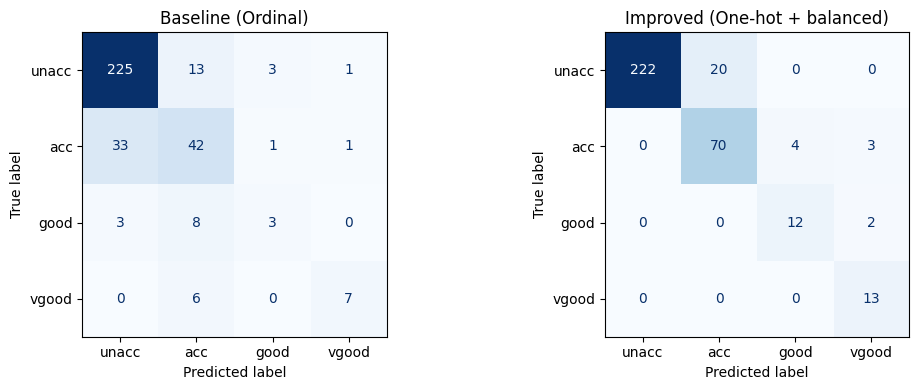

In [ ]:
best_model = LogisticRegression(max_iter=5000, C=10, class_weight='balanced', random_state=RANDOM_STATE)
best_model.fit(X_oh_train, y_train)
y_pred_best = best_model.predict(X_oh_test)

print(f'테스트 정확도: {accuracy_score(y_test, y_pred_best):.4f}\n')
print(classification_report(y_test, y_pred_best, target_names=class_order, digits=3))

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, pred, title in [(axes[0], y_pred, 'Baseline (Ordinal)'),
                        (axes[1], y_pred_best, 'Improved (One-hot + balanced)')]:
    ConfusionMatrixDisplay(confusion_matrix(y_test, pred), display_labels=class_order) \
        .plot(ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(title)
plt.tight_layout()
plt.show()

## 9. 계수 해석
기본 모델(순서형 인코딩)의 계수를 보면 각 변수가 어떤 등급 쪽으로 확률을 끌어올리는지 알 수 있습니다.
양수(빨강)이면 그 변수 값이 커질수록 해당 등급일 확률이 높아지고, 음수(파랑)이면 낮아집니다.

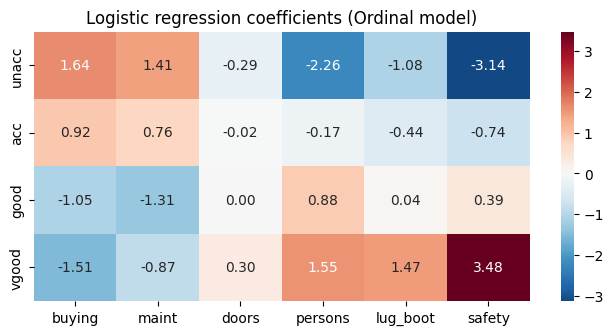

In [ ]:
coef = pd.DataFrame(model.coef_, index=class_order, columns=feature_cols)

plt.figure(figsize=(8, 3.5))
sns.heatmap(coef, annot=True, fmt='.2f', cmap='RdBu_r', center=0)
plt.title('Logistic regression coefficients (Ordinal model)')
plt.show()

> 예: `safety`와 `persons`는 `unacc` 행에서 큰 음수 → 안전성·탑승 인원이 클수록 ‘불가’ 판정 확률이 낮아집니다.
> `buying`, `maint`는 `vgood` 행에서 음수 → 가격·유지비가 비쌀수록 ‘매우 좋음’ 확률이 낮아집니다.

## 10. 새로운 자동차 예측해 보기

In [ ]:
new_cars = pd.DataFrame([
    ['low',   'low',  '4', 'more', 'big',   'high'],   # 싸고 넓고 안전한 차
    ['vhigh', 'high', '2', '2',    'small', 'med'],    # 비싸고 2인승
    ['med',   'med',  '4', '4',    'med',   'high'],   # 무난한 차
], columns=feature_cols)

X_new = oh_enc.transform(new_cars)
proba = best_model.predict_proba(pd.DataFrame(X_new, columns=X_oh.columns))

result = new_cars.copy()
result['예측 등급'] = [class_order[i] for i in proba.argmax(axis=1)]
for i, c in enumerate(class_order):
    result[f'P({c})'] = proba[:, i].round(3)
result

,buying,maint,doors,persons,lug_boot,safety,예측 등급,P(unacc),P(acc),P(good),P(vgood)
0,low,low,4,more,big,high,vgood,0.0,0.000,0.001,0.999
1,vhigh,high,2,2,small,med,unacc,1.0,0.000,0.000,0.000
2,med,med,4,4,med,high,vgood,0.0,0.007,0.079,0.914
